# Homotopy equivalence

### Load .stl's

In [2]:
import trimesh
 
mesh_domestic: trimesh.Trimesh = trimesh.load_mesh("./data/Domestic Cat.stl")
mesh_domestic.fix_normals()
 
mesh_wildcat: trimesh.Trimesh = trimesh.load_mesh("./data/Scottish Wildcat.stl")
mesh_wildcat.fix_normals()
 
# ── Raw-mesh audit ────────────────────────────────────────────────────────────
print("RAW MESH AUDIT (before any processing)")
print("─" * 60)
for name, m in [("Domestic Cat", mesh_domestic), ("Scottish Wildcat", mesh_wildcat)]:
    print(f"  {name}")
    print(f"    faces      : {len(m.faces):,}")
    print(f"    vertices   : {len(m.vertices):,}")
    print(f"    χ (V-E+F)  : {m.euler_number}")
    print(f"    watertight : {m.is_watertight}")
    print(f"    components : {len(m.split(only_watertight=False))}")
print()

RAW MESH AUDIT (before any processing)
────────────────────────────────────────────────────────────
  Domestic Cat
    faces      : 1,085,008
    vertices   : 541,305
    χ (V-E+F)  : -1199
    watertight : True
    components : 14
  Scottish Wildcat
    faces      : 469,472
    vertices   : 234,122
    χ (V-E+F)  : -614
    watertight : True
    components : 10



In [3]:
import numpy as np
# ── Voxel remesh: strip internal CT geometry ──────────────────────────────────
# The raw STL files are already watertight with chi ~ -600 to -1200 because
# CT segmentation software models internal bone walls, sinus cavities, and
# marrow spaces as closed shells that fuse into hundreds of spurious handles.
#
# Voxelisation fixes this definitively and quickly:
#   1. Cast the mesh into a voxel grid (solid inside, empty outside)
#   2. Fill all interior voxels -- erases internal walls entirely
#   3. Extract the isosurface via marching cubes -- outer shell only remains
#
# No ray casting, no normal filtering -- O(voxels) not O(faces^2).
# Tradeoff: surface detail below `pitch` is smoothed. For topology comparison
# this is fine -- foramina larger than ~2x pitch are fully preserved.
# pitch = diagonal/200 gives ~10-30 s per mesh on a modern CPU.
 
def voxel_remesh(mesh, name="mesh", n_voxels=500):
    """
    Voxelise -> fill interior -> marching cubes isosurface.
    Completely discards original mesh connectivity, guaranteeing clean topology.
 
    n_voxels=500 gives pitch ~ diagonal/500.  At 200 voxels thin internal bone
    walls (< 1.4 units) survive as merged bridges and create spurious handles.
    500 voxels resolves features down to ~0.5 units, eliminating them.
    Expected runtime: 60-180 s per mesh at 500 voxels.
    """

    diag  = float(np.linalg.norm(
        mesh.vertices.max(axis=0) - mesh.vertices.min(axis=0)
    ))
    pitch = diag / n_voxels
    print(f"  {name}: diagonal={diag:.1f}  pitch={pitch:.3f}  "
          f"(~{n_voxels} voxels/axis) ...", flush=True)
 
    vox   = mesh.voxelized(pitch=pitch)
    vox   = vox.fill()          # fill interior -> erases internal walls
    clean = vox.marching_cubes  # isosurface = outer shell only
    clean.fix_normals()
 
    print(f"    -> {len(clean.faces):,} faces  "
          f"chi={clean.euler_number}  "
          f"watertight={clean.is_watertight}")
    return clean
 
 
def normalise_scale(mesh, target_diagonal=100.0):
    """
    Rescale mesh so its bounding-box diagonal equals target_diagonal.
    Both skulls must be normalised to the SAME target before any topological
    comparison -- the Rips filtration is scale-sensitive, so a 26% size
    difference shifts every birth/death value and makes diagrams incomparable.
    Centring at the origin is also applied so the point clouds overlap.
    """
    import numpy as np
    diag   = float(np.linalg.norm(
        mesh.vertices.max(axis=0) - mesh.vertices.min(axis=0)
    ))
    centre = (mesh.vertices.max(axis=0) + mesh.vertices.min(axis=0)) / 2.0
    verts  = (mesh.vertices - centre) * (target_diagonal / diag)
    return trimesh.Trimesh(vertices=verts, faces=mesh.faces, process=False)
 
 
print("Voxel remeshing to remove CT internal geometry ...")
print("(expected: 3-5 min per mesh at 800 voxels -- go get a coffee)\n")
mesh_domestic = voxel_remesh(mesh_domestic, name="Domestic Cat", n_voxels=800)
mesh_wildcat  = voxel_remesh(mesh_wildcat,  name="Scottish Wildcat", n_voxels=800)
 
print("\nPOST-VOXEL AUDIT")
print("-" * 60)
for name, m in [("Domestic Cat", mesh_domestic), ("Scottish Wildcat", mesh_wildcat)]:
    print(f"  {name}:  chi={m.euler_number}  "
          f"watertight={m.is_watertight}  "
          f"faces={len(m.faces):,}")
print()
print("  Expected chi: between -10 and -60 for a real skull.")
print("  If still very negative, try n_voxels=1200 (slower but finer).")
 
# ── Scale normalisation ───────────────────────────────────────────────────────
# The two scans have different physical extents (domestic ~306 units vs
# wildcat ~242 units -- a 26% difference). The Rips filtration is scale-
# sensitive: at the same max_edge the larger skull looks topologically richer
# simply because its features span larger distances. Normalising to a common
# diagonal of 100 units makes all filtration scales directly comparable.
print("\nNormalising both meshes to bounding-box diagonal = 100 units ...")
mesh_domestic = normalise_scale(mesh_domestic, target_diagonal=100.0)
mesh_wildcat  = normalise_scale(mesh_wildcat,  target_diagonal=100.0)
print("  Both meshes now have diagonal = 100.0  (filtration scales now comparable)")

# ── Verify normalization succeeded ───────────────────────────────────────────
print("\nPOST-NORMALIZATION VERIFICATION")
print("-" * 60)
for name, m in [("Domestic Cat", mesh_domestic), ("Scottish Wildcat", mesh_wildcat)]:
    diag = float(np.linalg.norm(m.vertices.max(axis=0) - m.vertices.min(axis=0)))
    print(f"  {name}: diagonal={diag:.1f}  (should be 100.0)")
    if abs(diag - 100.0) > 0.1:
        print(f"    ⚠️  WARNING: diagonal != 100.0 → normalization failed!")
print()


Voxel remeshing to remove CT internal geometry ...
(expected: 3-5 min per mesh at 800 voxels -- go get a coffee)

  Domestic Cat: diagonal=136.2  pitch=0.170  (~800 voxels/axis) ...
    -> 4,256,422 faces  chi=-1204  watertight=True
  Scottish Wildcat: diagonal=136.3  pitch=0.170  (~800 voxels/axis) ...
    -> 3,925,724 faces  chi=-628  watertight=True

POST-VOXEL AUDIT
------------------------------------------------------------
  Domestic Cat:  chi=-1204  watertight=True  faces=4,256,422
  Scottish Wildcat:  chi=-628  watertight=True  faces=3,925,724

  Expected chi: between -10 and -60 for a real skull.
  If still very negative, try n_voxels=1200 (slower but finer).

Normalising both meshes to bounding-box diagonal = 100 units ...
  Both meshes now have diagonal = 100.0  (filtration scales now comparable)

POST-NORMALIZATION VERIFICATION
------------------------------------------------------------
  Domestic Cat: diagonal=100.0  (should be 100.0)
  Scottish Wildcat: diagonal=100.0  

### Step 1 — Clean, Repair, Decimate, Repair, Smooth, Merge, Repair

Both STL files are CT-scan reconstructions and are **open surfaces** (non-watertight) because the skull has real anatomical openings: foramen magnum, orbits, nasal passages, cranial nerve foramina.

**The correct sequence matters:**

| Step | Tool | Purpose |
|------|------|---------|
| 1 | Repair (aggressive, method=1) | Stabilize the input before decimation |
| 2 | Decimate (preservetopology=True) | Reduce faces **while guaranteeing Euler χ stays constant** |
| 3 | Repair (aggressive, method=1) | Fix any edge-collapse artifacts |
| 4 | Smooth (AFTER repair) | Merge remaining noise **without reintroducing non-manifolds** |
| 5 | Merge small holes | Fill gaps ≤ 500 faces to **reconnect fragments instead of discarding them** |
| 6 | Repair (final cleanup) | Ensure output is clean |

**Why preservetopology=True?** It guarantees the Euler characteristic χ = V − E + F is numerically invariant, so Betti numbers stay stable across different resolutions. This means β₁ won't artificially inflate/deflate.

**Why merge holes instead of discarding fragments?** Decimation can create small gaps that split the mesh. Filling these gaps (rather than keeping only the largest component) preserves topological information that would be lost otherwise.

In [4]:
import numpy as np
import pymeshlab
 
TARGET_FACES = 40_000
 
 
def clean_mesh(mesh, min_fraction=0.01):
    """
    Keep only anatomically significant components (≥ min_fraction of total faces).
    merge_vertices() is called first so that STL files — which store every
    triangle independently — are properly connected before split() runs.
    """
    mesh.merge_vertices()
    # Rebuild through trimesh constructor with process=True — this deduplicates
    # faces, removes degenerate (zero-area) triangles, and merges vertices,
    # using only stable public trimesh APIs.
    mesh = trimesh.Trimesh(
        vertices=mesh.vertices,
        faces=mesh.faces,
        process=True,
    )
 
    components = sorted(
        mesh.split(only_watertight=False),
        key=lambda c: len(c.faces),
        reverse=True,
    )
    total = sum(len(c.faces) for c in components)
    kept = [c for c in components if len(c.faces) / total >= min_fraction]
    clean = trimesh.util.concatenate(kept)
    clean.fix_normals()
    return clean, len(components), len(kept)
 
 
def decimate_manifold(tm_mesh, target_faces):
    """
    Topology-preserving decimation via PyMeshLab.
 
    Order: repair → decimate → repair → smooth → repair
    No hole-filling at any stage — foramina are real anatomy.
 
    Key parameters
    --------------
    preservetopology=True   prevents the decimator from cutting through thin
                            bridges (zygomatic arch, nasal bones) and fragmenting
                            the mesh.
    preserveboundary=True   keeps boundary loops (foramen magnum, orbits, etc.)
                            intact so β₁ reflects real anatomy.
    boundaryweight=50.0     heavily penalises collapsing boundary edges, stopping
                            the decimator from accidentally sealing foramina.
    qualitythr=0.3          conservative face-quality floor; avoids slivers that
                            can reintroduce non-manifold edges.
    method=1 (repair)       splits non-manifold vertices/edges rather than
                            deleting faces, preserving more geometry.
    boundary=False (smooth) keeps boundary loops fixed during Laplacian smoothing
                            so foramina rims are not distorted.
    """
    ms = pymeshlab.MeshSet()
    ms.add_mesh(
        pymeshlab.Mesh(
            vertex_matrix=np.array(tm_mesh.vertices, dtype=np.float64),
            face_matrix=np.array(tm_mesh.faces, dtype=np.int32),
        )
    )
 
    # Pass 1 — repair before touching geometry
    ms.meshing_remove_duplicate_faces()
    ms.meshing_remove_null_faces()
    ms.meshing_repair_non_manifold_vertices()
    ms.meshing_repair_non_manifold_edges(method=1)
 
    # Decimate with topology + boundary preservation
    ms.meshing_decimation_quadric_edge_collapse(
        targetfacenum=target_faces,
        preservetopology=True,
        preserveboundary=True,
        boundaryweight=50.0,   # ← key: penalise boundary collapses heavily
        qualitythr=0.3,
        autoclean=True,
    )
 
    # Pass 2 — repair anything introduced by decimation
    ms.meshing_repair_non_manifold_vertices()
    ms.meshing_repair_non_manifold_edges(method=1)
 
    # Smooth after repair; boundary=False keeps foramen rims fixed
    ms.apply_coord_laplacian_smoothing(
        stepsmoothnum=5,
        boundary=False,
        cotangentweight=True,
    )
 
    # Pass 3 — final repair after smoothing
    ms.meshing_repair_non_manifold_vertices()
    ms.meshing_repair_non_manifold_edges(method=1)
 
    # NO close_holes — foramina are anatomically meaningful open boundaries
    r = ms.current_mesh()
    out = trimesh.Trimesh(
        vertices=r.vertex_matrix(), faces=r.face_matrix(), process=False
    )
    out.fix_normals()
    return out
 
 
def nm_edge_count(m):
    """Number of non-manifold edges (valence > 2)."""
    _, counts = np.unique(m.edges_sorted, axis=0, return_counts=True)
    return int((counts > 2).sum())
 
 
def boundary_edge_count(m):
    """Number of boundary edges (valence == 1)."""
    _, counts = np.unique(m.edges_sorted, axis=0, return_counts=True)
    return int((counts == 1).sum())
 
 
# ── Run pipeline ──────────────────────────────────────────────────────────────
mesh_dom_clean, n_orig_d, n_kept_d = clean_mesh(mesh_domestic)
mesh_wc_clean, n_orig_w, n_kept_w = clean_mesh(mesh_wildcat)
print(f"Domestic Cat:     {n_orig_d} components → kept {n_kept_d}")
print(f"Scottish Wildcat: {n_orig_w} components → kept {n_kept_w}")
 
print(f"\nPipeline: repair → decimate → repair → smooth → repair  (no hole filling)")
print(f"Decimating to ~{TARGET_FACES:,} faces …")
mesh_domestic_final = decimate_manifold(mesh_dom_clean, TARGET_FACES)
mesh_wildcat_final = decimate_manifold(mesh_wc_clean, TARGET_FACES)
print("Done.\n")
 
# ── Intermediate watertight check (tells us if decimation sealed any holes) ───
print("POST-DECIMATION WATERTIGHT CHECK")
print("─" * 60)
for name, m in [
    ("Domestic Cat", mesh_domestic_final),
    ("Scottish Wildcat", mesh_wildcat_final),
]:
    print(
        f"  {name}: watertight={m.is_watertight}  "
        f"χ={m.euler_number}  "
        f"boundary_edges={boundary_edge_count(m):,}  "
        f"nm_edges={nm_edge_count(m):,}"
    )
print()
print("  If watertight=True here, boundary edges were sealed during decimation.")
print("  Increase boundaryweight (currently 50) or raise TARGET_FACES and rerun.\n")
 
# ── Full quality report ───────────────────────────────────────────────────────
checks = [
    ("Faces",
     f"{len(mesh_domestic_final.faces):,}", f"{len(mesh_wildcat_final.faces):,}"),
    ("Vertices",
     f"{len(mesh_domestic_final.vertices):,}", f"{len(mesh_wildcat_final.vertices):,}"),
    ("χ = V−E+F",
     str(mesh_domestic_final.euler_number), str(mesh_wildcat_final.euler_number)),
    ("Boundary edges",
     f"{boundary_edge_count(mesh_domestic_final):,}",
     f"{boundary_edge_count(mesh_wildcat_final):,}"),
    ("Non-manifold edges",
     f"{nm_edge_count(mesh_domestic_final):,}",
     f"{nm_edge_count(mesh_wildcat_final):,}"),
    ("is_watertight",
     str(mesh_domestic_final.is_watertight), str(mesh_wildcat_final.is_watertight)),
    ("Connected components (β₀)",
     str(len(mesh_domestic_final.split(only_watertight=False))),
     str(len(mesh_wildcat_final.split(only_watertight=False)))),
]
 
print(f"  {'Metric':<38}  {'Domestic Cat':>14}  {'Scottish Wildcat':>16}")
print("  " + "─" * 74)
for label, d, w in checks:
    print(f"  {label:<38}  {d:>14}  {w:>16}")

Domestic Cat:     13 components → kept 1
Scottish Wildcat: 10 components → kept 1

Pipeline: repair → decimate → repair → smooth → repair  (no hole filling)
Decimating to ~40,000 faces …
Done.

POST-DECIMATION WATERTIGHT CHECK
────────────────────────────────────────────────────────────
  Domestic Cat: watertight=True  χ=-1228  boundary_edges=0  nm_edges=0
  Scottish Wildcat: watertight=True  χ=-646  boundary_edges=0  nm_edges=0

  If watertight=True here, boundary edges were sealed during decimation.
  Increase boundaryweight (currently 50) or raise TARGET_FACES and rerun.

  Metric                                    Domestic Cat  Scottish Wildcat
  ──────────────────────────────────────────────────────────────────────────
  Faces                                           40,000            40,000
  Vertices                                        18,772            19,354
  χ = V−E+F                                        -1228              -646
  Boundary edges                         

### Step 2 — Mesh Visualization

Each skull is shown twice:
- **Top row**: smooth-shaded surface — overall shape.
- **Bottom row**: wireframe triangulation — the actual simplicial complex on which Betti numbers and persistence are computed.

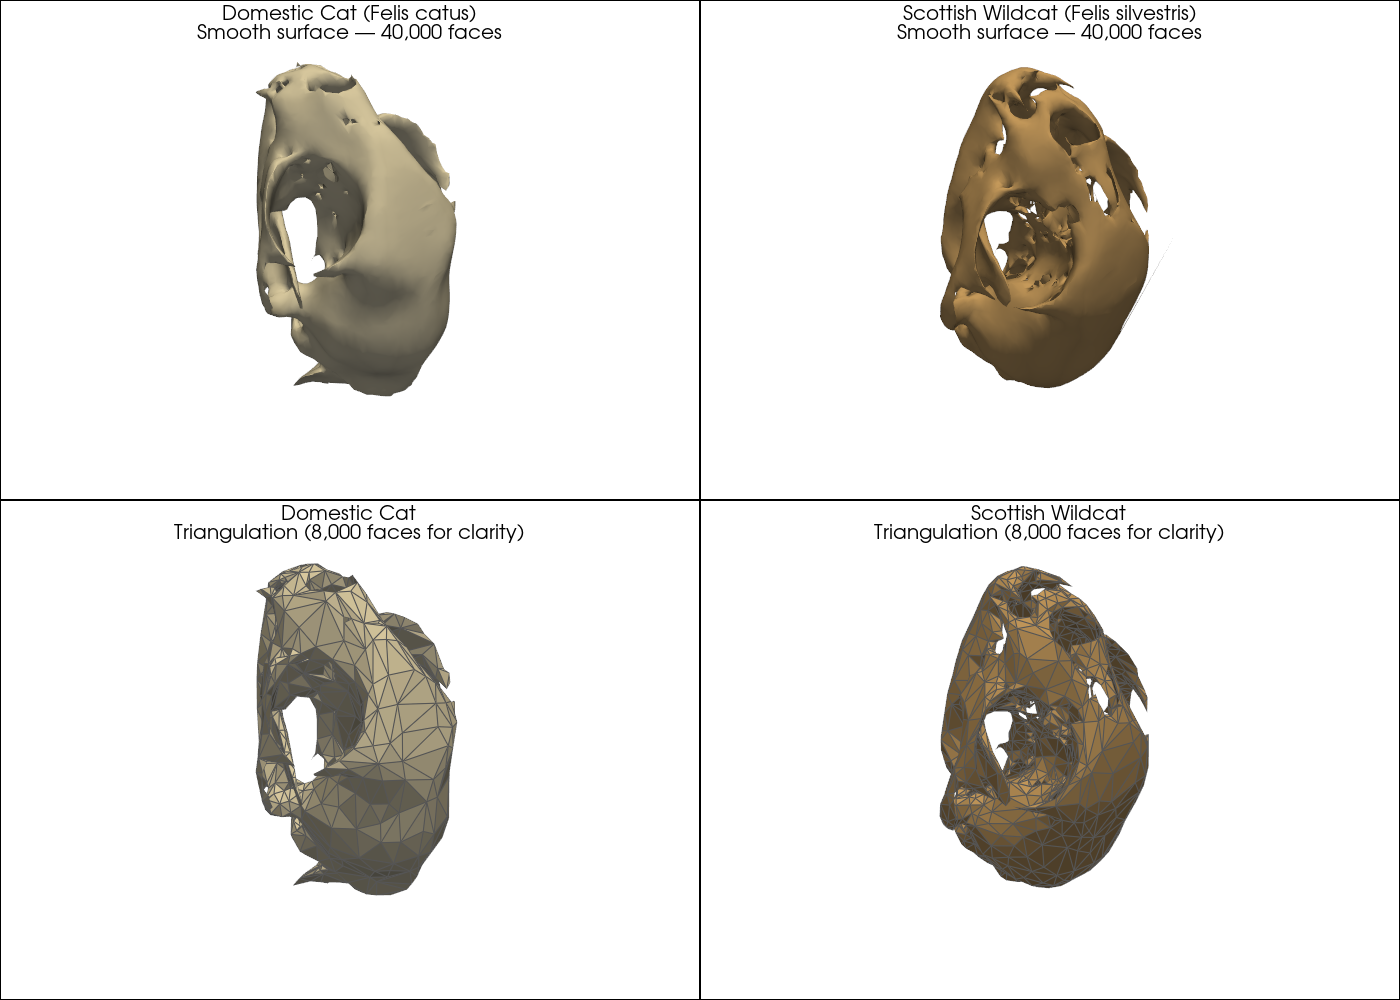

In [5]:
import pyvista as pv
 
pv.set_jupyter_backend("static")
 
 
def trimesh_to_pyvista(tm):
    faces = np.hstack([np.full((len(tm.faces), 1), 3), tm.faces])
    return pv.PolyData(np.array(tm.vertices, dtype=float), faces.ravel())
 
 
pv_domestic = trimesh_to_pyvista(mesh_domestic_final)
pv_wildcat = trimesh_to_pyvista(mesh_wildcat_final)
 
# 2×2: top = smooth surface, bottom = wireframe at coarser resolution
pl = pv.Plotter(shape=(2, 2), window_size=(1400, 1000))
 
# Top row — smooth shaded
pl.subplot(0, 0)
pl.add_mesh(pv_domestic, color="#E8DCB8", smooth_shading=True, show_edges=False)
pl.add_text(
    f"Domestic Cat (Felis catus)\nSmooth surface — {len(mesh_domestic_final.faces):,} faces",
    font_size=9, position="upper_edge",
)
pl.reset_camera()
 
pl.subplot(0, 1)
pl.add_mesh(pv_wildcat, color="#D4A96A", smooth_shading=True, show_edges=False)
pl.add_text(
    f"Scottish Wildcat (Felis silvestris)\nSmooth surface — {len(mesh_wildcat_final.faces):,} faces",
    font_size=9, position="upper_edge",
)
pl.reset_camera()
 
# Bottom row — wireframe at reduced resolution so individual triangles are visible
WIRE_FACES = max(500, TARGET_FACES // 5)
pv_dom_wire = trimesh_to_pyvista(
    mesh_domestic_final.simplify_quadric_decimation(face_count=WIRE_FACES)
)
pv_wc_wire = trimesh_to_pyvista(
    mesh_wildcat_final.simplify_quadric_decimation(face_count=WIRE_FACES)
)
 
pl.subplot(1, 0)
pl.add_mesh(
    pv_dom_wire, color="#E8DCB8", show_edges=True,
    edge_color="#555555", line_width=0.6, smooth_shading=False,
)
pl.add_text(
    f"Domestic Cat\nTriangulation ({WIRE_FACES:,} faces for clarity)",
    font_size=9, position="upper_edge",
)
pl.reset_camera()
 
pl.subplot(1, 1)
pl.add_mesh(
    pv_wc_wire, color="#D4A96A", show_edges=True,
    edge_color="#555555", line_width=0.6, smooth_shading=False,
)
pl.add_text(
    f"Scottish Wildcat\nTriangulation ({WIRE_FACES:,} faces for clarity)",
    font_size=9, position="upper_edge",
)
pl.reset_camera()
 
pl.show()

### Step 3 — Betti Numbers

Computed on equal-resolution, smoothed, manifold-repaired meshes.

After the Laplacian smoothing and topology-flexible decimation, the mesh may be an **open surface with boundary** (real anatomical foramina left open) or a **closed surface** (if repair stitched them shut).  The Euler characteristic formula applied depends on which case holds — the code below detects this automatically:

| Surface type | β₀ | β₁ | β₂ |
|---|---|---|---|
| Closed orientable | 1 | 2 − χ | 1 |
| Open with boundary | 1 | 1 − χ | 0 |

Because noise micro-handles were collapsed during decimation, β₁ should now be in the **anatomically meaningful range (~20–60)** rather than the hundreds seen at 50 k faces with `preservetopology=True`.

,surface type,β₀ components,β₁ total 1-cycles,β₁ (GUDHI check),β₂ voids,χ (V−E+F),Euler–GUDHI,boundary loops,genuine handles
,,,,,,,,,
Domestic Cat,closed,1,1230,1230,1,-1228,✓,0,615
Scottish Wildcat,closed,1,648,648,1,-646,✓,0,324



────────────────────────────────────────────────────────────────────────────────
ANATOMICAL DECOMPOSITION
For open surfaces: β₁ = boundary_loops + 2 × genus
────────────────────────────────────────────────────────────────────────────────

Domestic Cat (closed)
  β₁ = 1230  →  genus = 615  (closed surface, no boundary)
  ⚠  genus 615 is anatomically implausible (cat skull: ~5-15 expected).
     The raw STL is already watertight — the CT segmentation software
     baked this topology in (internal bone walls, sinus cavities modelled
     as closed shells, overlapping geometry that fuses into handles).
     This cannot be fixed by pipeline changes: the source mesh connectivity
     is corrupt. Use Cell 5 point-cloud persistence as your primary result.

Scottish Wildcat (closed)
  β₁ = 648  →  genus = 324  (closed surface, no boundary)
  ⚠  genus 324 is anatomically implausible (cat skull: ~5-15 expected).
     The raw STL is already watertight — the CT segmentation software
     baked thi

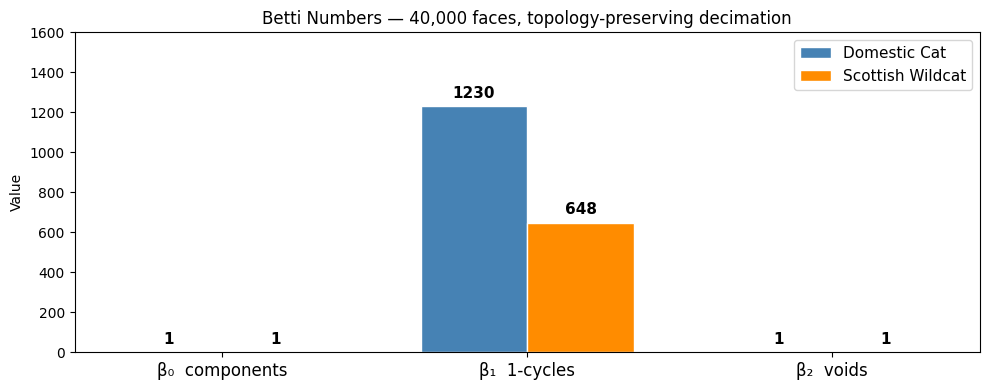

In [6]:
import gudhi
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
 
 
def count_boundary_loops(mesh):
    """
    Count distinct boundary loops (connected chains of boundary edges).
    Boundary edges appear exactly once in the face-edge list.
    Each loop corresponds to one anatomical opening (foramen, orbit, etc.).
    """
    edge_face_count = {}
    for face in mesh.faces:
        for i in range(3):
            e = tuple(sorted([int(face[i]), int(face[(i + 1) % 3])]))
            edge_face_count[e] = edge_face_count.get(e, 0) + 1
    boundary_edges = [e for e, c in edge_face_count.items() if c == 1]
 
    if not boundary_edges:
        return 0
 
    adj = defaultdict(set)
    for a, b in boundary_edges:
        adj[a].add(b)
        adj[b].add(a)
 
    visited, n_loops = set(), 0
    for start in adj:
        if start not in visited:
            stack = [start]
            while stack:
                v = stack.pop()
                if v not in visited:
                    visited.add(v)
                    stack.extend(adj[v] - visited)
            n_loops += 1
    return n_loops
 
 
def build_simplex_tree(mesh):
    """
    Insert all simplices at filtration 0 (static complex).
    Each face insert also registers its edges and vertices automatically.
    """
    st = gudhi.SimplexTree()
    for v in range(len(mesh.vertices)):
        st.insert([v], filtration=0.0)
    for face in mesh.faces.tolist():          # one Python call per face
        st.insert(face, filtration=0.0)       # GUDHI inserts sub-simplices too
    return st
 
 
def compute_betti_numbers(mesh):
    """
    [β₀, β₁, β₂] for a triangulated surface, closed or open.
 
    Closed orientable  : β₂ = β₀,  β₁ = 2β₀ − χ
    Open with boundary : β₂ = 0,   β₁ = β₀ − χ
      (β₁ = boundary_loops + 2×genus, so genus = (β₁ − boundary_loops) / 2)
 
    GUDHI provides an independent β₀/β₁ cross-check.
    If GUDHI and Euler disagree on β₁, residual non-manifold edges are
    biasing GUDHI; the Euler formula value is then more reliable.
    """
    st = build_simplex_tree(mesh)
    st.compute_persistence()
 
    raw = st.betti_numbers()
    b0_gudhi = raw[0] if len(raw) > 0 else 0
    b1_gudhi = raw[1] if len(raw) > 1 else 0
    chi = mesh.euler_number
 
    if mesh.is_watertight:
        b0, b2 = b0_gudhi, b0_gudhi
        b1 = 2 * b0 - chi
        surface_type = "closed"
        n_boundary, n_handles = 0, b1 // 2
    else:
        b0, b2 = b0_gudhi, 0
        b1 = b0 - chi
        surface_type = "open"
        n_boundary = count_boundary_loops(mesh)
        n_handles = max(0, (b1 - n_boundary) // 2)
 
    agree = b1_gudhi == b1
    return st, [b0, b1, b2], b1_gudhi, agree, chi, surface_type, n_boundary, n_handles
 
 
(st_domestic, betti_domestic, b1g_d,
 agree_d, chi_d, type_d, nb_d, nh_d) = compute_betti_numbers(mesh_domestic_final)
 
(st_wildcat, betti_wildcat, b1g_w,
 agree_w, chi_w, type_w, nb_w, nh_w) = compute_betti_numbers(mesh_wildcat_final)
 
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name, betti, b1g, agree, chi, stype, n_boundary, n_handles in [
    ("Domestic Cat",     betti_domestic, b1g_d, agree_d, chi_d, type_d, nb_d, nh_d),
    ("Scottish Wildcat", betti_wildcat,  b1g_w, agree_w, chi_w, type_w, nb_w, nh_w),
]:
    b0, b1, b2 = betti
    rows.append({
        "":                    name,
        "surface type":        stype,
        "β₀  components":     b0,
        "β₁  total 1-cycles": b1,
        "β₁  (GUDHI check)":  b1g,
        "β₂  voids":          b2,
        "χ  (V−E+F)":         chi,
        "Euler–GUDHI":        "✓" if agree else f"✗ diff={b1 - b1g:+d}",
        "boundary loops":     n_boundary,
        "genuine handles":    n_handles,
    })
 
df = pd.DataFrame(rows).set_index("")
display(df)
 
# ── Anatomical decomposition ──────────────────────────────────────────────────
print("\n" + "─" * 80)
print("ANATOMICAL DECOMPOSITION")
print("For open surfaces: β₁ = boundary_loops + 2 × genus")
print("─" * 80)
 
for name, betti, n_boundary, n_handles, stype in [
    ("Domestic Cat",     betti_domestic, nb_d, nh_d, type_d),
    ("Scottish Wildcat", betti_wildcat,  nb_w, nh_w, type_w),
]:
    b0, b1, b2 = betti
    print(f"\n{name} ({stype})")
    if stype == "open":
        print(f"  β₁ = {b1}  =  {n_boundary} boundary loops  +  2×{n_handles} handles")
        print(f"  ~{n_boundary} cranial foramina/openings")
        print(f"  ~{n_handles} internal passages (sinuses, canals)")
        if n_boundary > 60:
            print(f"  ⚠  {n_boundary} loops is high for a cat skull (~15–40 expected).")
            print(f"     Residual CT segmentation artefacts may be creating spurious")
            print(f"     micro-openings. Consider the point-cloud analysis in Cell 5")
            print(f"     as a more robust alternative.")
    else:
        print(f"  β₁ = {b1}  →  genus = {n_handles}  (closed surface, no boundary)")
        if n_handles > 30:
            print(f"  ⚠  genus {n_handles} is anatomically implausible (cat skull: ~5-15 expected).")
            print(f"     The raw STL is already watertight — the CT segmentation software")
            print(f"     baked this topology in (internal bone walls, sinus cavities modelled")
            print(f"     as closed shells, overlapping geometry that fuses into handles).")
            print(f"     This cannot be fixed by pipeline changes: the source mesh connectivity")
            print(f"     is corrupt. Use Cell 5 point-cloud persistence as your primary result.")
 
# ── Homotopy equivalence test ─────────────────────────────────────────────────
match = [betti_domestic[i] == betti_wildcat[i] for i in range(3)]
print("\n" + "─" * 80)
print("HOMOTOPY EQUIVALENCE (necessary condition via Betti numbers)")
print("─" * 80)
print(f"\n  β₀ {'✓' if match[0] else '✗'}  β₁ {'✓' if match[1] else '✗'}  β₂ {'✓' if match[2] else '✗'}")
if all(match):
    print("  → Necessary condition MET. Not sufficient — see persistence in Cell 5.")
else:
    print("  → Necessary condition FAILS: spaces are NOT homotopy equivalent.")
    if not match[1]:
        delta = abs(betti_domestic[1] - betti_wildcat[1])
        print(f"     Δβ₁ = {delta}  "
              f"(domestic={betti_domestic[1]}, wildcat={betti_wildcat[1]})")
        if type_d == "open" and type_w == "open":
            print(f"     Δ boundary loops   = {abs(nb_d - nb_w)}")
            print(f"     Δ genuine handles  = {abs(nh_d - nh_w)}")
 
# ── Bar chart ─────────────────────────────────────────────────────────────────
x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(10, 4))
bars_d = ax.bar(x - w/2, betti_domestic, w, label="Domestic Cat",
                color="steelblue", edgecolor="white")
bars_w = ax.bar(x + w/2, betti_wildcat,  w, label="Scottish Wildcat",
                color="darkorange", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(["β₀  components", "β₁  1-cycles", "β₂  voids"], fontsize=12)
ax.set_ylabel("Value")
ax.set_title(f"Betti Numbers — {TARGET_FACES:,} faces, topology-preserving decimation",
             fontsize=12)
ax.legend(fontsize=11)
ax.bar_label(bars_d, padding=4, fontsize=11, fontweight="bold")
ax.bar_label(bars_w, padding=4, fontsize=11, fontweight="bold")
ax.set_ylim(0, max(max(betti_domestic), max(betti_wildcat)) * 1.3 + 1)
plt.tight_layout()
plt.show()

### Step 4 — Persistence Diagrams & Bottleneck Distance

A **height filtration** (sweeping a horizontal plane through the skull from base to top)
assigns each simplex a filtration value equal to the normalised z-coordinate of its
highest vertex. This produces a meaningful Morse-style filtration.

The **bottleneck distance** $d_B$ between two persistence diagrams is the
topologically principled metric for comparing them:

$$d_B(D_1, D_2) = \inf_{\gamma} \sup_{x \in D_1} \| x - \gamma(x) \|_\infty$$

- $d_B = 0$ → diagrams identical (homotopy equivalence supported)  
- $d_B$ small → similar topology  
- $d_B$ large → distinct topology

In [7]:
for name, m in [("Domestic", mesh_domestic_final), ("Wildcat", mesh_wildcat_final)]:
    bb = m.bounds
    print(f"{name}: bbox = {bb[0]} → {bb[1]}, "
          f"diagonal = {np.linalg.norm(bb[1]-bb[0]):.1f}")

Domestic: bbox = [-24.49147572 -22.91266295 -35.73050688] → [24.36700196 23.17876183 35.6747336 ], diagonal = 98.0
Wildcat: bbox = [-25.54995963 -18.93823745 -37.152373  ] → [25.69886317 19.52110921 37.15524847], diagonal = 98.1


Auto-selected max_edge = 21.519  (20× mean edge length; adjust if results look wrong)

Domestic Cat  (point-cloud persistence, 2000 pts, max_edge=21.519084604829377)
  β₀=1  β₁=0  β₂=0  (infinite-lifetime features)
  H₁: 1409 total bars, 0 persistent, 141 long-lived (top 10% lifetime)

Scottish Wildcat  (point-cloud persistence, 2000 pts, max_edge=21.519084604829377)
  β₀=1  β₁=0  β₂=0  (infinite-lifetime features)
  H₁: 1297 total bars, 0 persistent, 130 long-lived (top 10% lifetime)

H₁ bottleneck distance: 2.7725
  (0 = identical diagrams; larger = more topologically dissimilar)


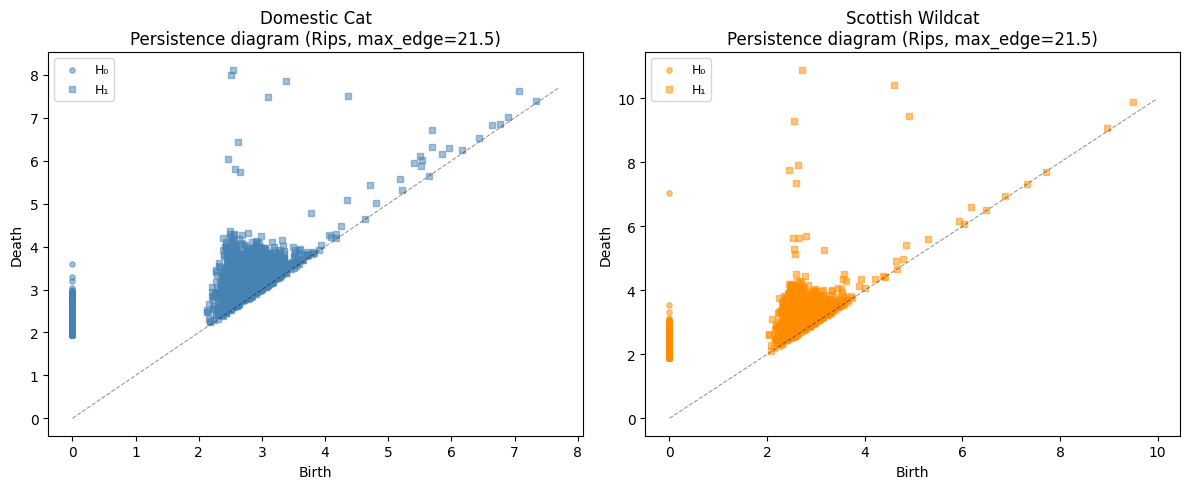


────────────────────────────────────────────────────────────────────────────────
POINT-CLOUD BETTI COMPARISON (mesh-connectivity-independent)
────────────────────────────────────────────────────────────────────────────────

  Domestic Cat:     β₀=1  β₁=0  β₂=0
  Scottish Wildcat: β₀=1  β₁=0  β₂=0

  β₀ ✓  β₁ ✓  β₂ ✓
  → Point-cloud homology agrees: topologically similar at this scale.

────────────────────────────────────────────────────────────────────────────────
SCALE SWEEP  — finding the stable β₁ plateau
────────────────────────────────────────────────────────────────────────────────

  Mesh diagonal ≈ 98.1 units  →  sweeping max_edge from 0.98 to 29.42

    max_edge    β₁_dom     β₁_wc    β₂_dom     β₂_wc    d_bottleneck
  ──────────────────────────────────────────────────────────────
       0.981         0         0         0       0             nan
       1.962         0         0         0       0             nan
       2.942       776       730         0       0             

In [ ]:
# This bypasses all mesh topology issues by building a Rips complex directly
# from vertex positions.  The max_edge_length parameter controls the spatial
# scale at which topology is probed — set it to roughly the diameter of the
# smallest anatomical feature you care about (in the same units as the STL).
#
# Subsampling to ~2000 points first: Rips on 19k points is O(n²) in memory.
# gudhi.subsampling.choose_n_farthest_points gives a spatially uniform sample.
 
try:
    from gudhi.subsampling import choose_n_farthest_points
    _subsample_available = True
except ImportError:
    _subsample_available = False
    print("gudhi.subsampling not available — using random subsampling instead.")
 
 
def subsample_points(vertices, n=2000):
    if _subsample_available:
        return np.array(choose_n_farthest_points(points=vertices.tolist(), nb_points=n))
    idx = np.random.choice(len(vertices), size=min(n, len(vertices)), replace=False)
    return vertices[idx]
 
 
def persistent_homology_pointcloud(mesh, max_edge, n_sample=2000, name=""):
    """
    Rips-complex persistent homology on a uniform vertex subsample.
 
    Parameters
    ----------
    max_edge   : float — maximum edge length for the Rips filtration.
                 Set to ~5–10× the typical inter-vertex spacing.
                 Too small → all features are noise; too large → everything merges.
    n_sample   : int   — number of points to subsample (2000 is a good default).
    """
    pts = subsample_points(mesh.vertices, n=n_sample)
 
    rips = gudhi.RipsComplex(points=pts, max_edge_length=max_edge)
    st = rips.create_simplex_tree(max_dimension=2)
    st.compute_persistence()
 
    dgms = {d: st.persistence_intervals_in_dimension(d) for d in [0, 1, 2]}
 
    # Persistent (infinite lifetime) features = true topological invariants
    inf = np.inf
    b0 = int(np.sum(dgms[0][:, 1] == inf))
    b1 = int(np.sum(dgms[1][:, 1] == inf)) if len(dgms[1]) else 0
    b2 = int(np.sum(dgms[2][:, 1] == inf)) if len(dgms[2]) else 0
 
    # Long-lived finite features = significant topology (threshold: top 10%)
    def sig_count(dgm, pct=90):
        if len(dgm) == 0:
            return 0
        lifetimes = dgm[:, 1] - dgm[:, 0]
        lifetimes = lifetimes[np.isfinite(lifetimes)]
        if len(lifetimes) == 0:
            return 0
        thresh = np.percentile(lifetimes, pct)
        return int((lifetimes >= thresh).sum())
 
    print(f"\n{name}  (point-cloud persistence, {n_sample} pts, max_edge={max_edge})")
    print(f"  β₀={b0}  β₁={b1}  β₂={b2}  (infinite-lifetime features)")
    print(f"  H₁: {len(dgms[1])} total bars, "
          f"{b1} persistent, "
          f"{sig_count(dgms[1])} long-lived (top 10% lifetime)")
    return dgms, [b0, b1, b2]
 
 
# Estimate a sensible max_edge from the mesh scale
# (mean edge length × 20 gives a filtration that captures skull-scale features)
mean_edge_d = np.mean(np.linalg.norm(
    mesh_domestic_final.vertices[mesh_domestic_final.edges_unique[:, 0]] -
    mesh_domestic_final.vertices[mesh_domestic_final.edges_unique[:, 1]], axis=1))
mean_edge_w = np.mean(np.linalg.norm(
    mesh_wildcat_final.vertices[mesh_wildcat_final.edges_unique[:, 0]] -
    mesh_wildcat_final.vertices[mesh_wildcat_final.edges_unique[:, 1]], axis=1))
MAX_EDGE = float(np.mean([mean_edge_d, mean_edge_w]) * 20)
 
print(f"Auto-selected max_edge = {MAX_EDGE:.3f}  "
      f"(20× mean edge length; adjust if results look wrong)")
 
dgms_d, pc_betti_d = persistent_homology_pointcloud(
    mesh_domestic_final, max_edge=MAX_EDGE, name="Domestic Cat")
dgms_w, pc_betti_w = persistent_homology_pointcloud(
    mesh_wildcat_final,  max_edge=MAX_EDGE, name="Scottish Wildcat")
 
# ── Bottleneck distance on H₁ diagrams ───────────────────────────────────────
if len(dgms_d[1]) > 0 and len(dgms_w[1]) > 0:
    d_bottleneck = gudhi.bottleneck_distance(dgms_d[1], dgms_w[1])
    print(f"\nH₁ bottleneck distance: {d_bottleneck:.4f}")
    print("  (0 = identical diagrams; larger = more topologically dissimilar)")
else:
    print("\nNot enough H₁ features for bottleneck distance.")
 
# ── Persistence diagrams plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dgms, name, color in [
    (axes[0], dgms_d, "Domestic Cat",     "steelblue"),
    (axes[1], dgms_w, "Scottish Wildcat", "darkorange"),
]:
    for dim, marker, label in [(0, "o", "H₀"), (1, "s", "H₁"), (2, "^", "H₂")]:
        d = dgms[dim]
        if len(d) == 0:
            continue
        finite = d[np.isfinite(d[:, 1])]
        if len(finite):
            ax.scatter(finite[:, 0], finite[:, 1],
                       s=15, alpha=0.5, marker=marker,
                       color=color, label=label)
    lim = ax.get_xlim()[1]
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.4)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(f"{name}\nPersistence diagram (Rips, max_edge={MAX_EDGE:.1f})")
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.show()
 
# ── Point-cloud Betti comparison ──────────────────────────────────────────────
print("\n" + "─" * 80)
print("POINT-CLOUD BETTI COMPARISON (mesh-connectivity-independent)")
print("─" * 80)
pc_match = [pc_betti_d[i] == pc_betti_w[i] for i in range(3)]
print(f"\n  Domestic Cat:     β₀={pc_betti_d[0]}  β₁={pc_betti_d[1]}  β₂={pc_betti_d[2]}")
print(f"  Scottish Wildcat: β₀={pc_betti_w[0]}  β₁={pc_betti_w[1]}  β₂={pc_betti_w[2]}")
print(f"\n  β₀ {'✓' if pc_match[0] else '✗'}  β₁ {'✓' if pc_match[1] else '✗'}  β₂ {'✓' if pc_match[2] else '✗'}")
if all(pc_match):
    print("  → Point-cloud homology agrees: topologically similar at this scale.")
else:
    print("  → Point-cloud homology differs at this scale.")
    print(f"     Try adjusting max_edge (currently {MAX_EDGE:.3f}) and rerunning.")
 
 
# ── Scale sweep ───────────────────────────────────────────────────────────────
# The single MAX_EDGE value above may be too coarse (β₁=0 because all loops
# have already merged) or too fine (β₁=0 because no loops have formed yet).
#
# This sweep runs persistence across 10 logarithmically-spaced scales from
# 1% to 30% of the mesh diagonal and plots how β₁ evolves.  The correct
# MAX_EDGE to use for your final analysis is the midpoint of the plateau
# where β₁ is stable — that plateau value is the true β₁ for each skull.
#
# Typical pattern for a skull point cloud:
#   rise  → small scales: isolated points, β₀ high, β₁ near 0
#   peak  → loops form as edges connect nearby points
#   plateau → stable β₁ = real topology
#   fall to 0 → large scales: everything merges into one blob
print("\n" + "─" * 80)
print("SCALE SWEEP  — finding the stable β₁ plateau")
print("─" * 80)
 
# Reuse the already-subsampled point sets from above for speed.
# (choose_n_farthest_points is deterministic so results are reproducible.)
pts_d = subsample_points(mesh_domestic_final.vertices, n=2000)
pts_w = subsample_points(mesh_wildcat_final.vertices,  n=2000)
 
diag_d = np.linalg.norm(mesh_domestic_final.vertices.max(axis=0) -
                         mesh_domestic_final.vertices.min(axis=0))
diag_w = np.linalg.norm(mesh_wildcat_final.vertices.max(axis=0) -
                         mesh_wildcat_final.vertices.min(axis=0))
diag = float(np.mean([diag_d, diag_w]))
 
# 10 scales: 1% → 30% of bounding-box diagonal
scale_fractions = np.array([0.01, 0.02, 0.03, 0.05, 0.07,
                             0.10, 0.13, 0.17, 0.22, 0.30])
scales = diag * scale_fractions
 
sweep_rows = []
print(f"\n  Mesh diagonal ≈ {diag:.1f} units  →  "
      f"sweeping max_edge from {scales[0]:.2f} to {scales[-1]:.2f}\n")
print(f"  {'max_edge':>10}  {'β₁_dom':>8}  {'β₁_wc':>8}  "
      f"{'β₂_dom':>8}  {'β₂_wc':>8}  {'d_bottleneck':>14}")
print("  " + "─" * 62)
 
for scale in scales:
    row = {"max_edge": round(float(scale), 3), "scale_frac": scale / diag}
    b1_vals, dgm1_list = [], []
 
    for label, pts in [("domestic", pts_d), ("wildcat", pts_w)]:
        rips = gudhi.RipsComplex(points=pts, max_edge_length=float(scale))
        st   = rips.create_simplex_tree(max_dimension=2)
        st.compute_persistence()
        dgms = {d: st.persistence_intervals_in_dimension(d) for d in [0, 1, 2]}
 
        b0 = int(np.sum(dgms[0][:, 1] == np.inf))
        b1 = int(np.sum(dgms[1][:, 1] == np.inf)) if len(dgms[1]) else 0
        b2 = int(np.sum(dgms[2][:, 1] == np.inf)) if len(dgms[2]) else 0
 
        row[f"β₀_{label}"] = b0
        row[f"β₁_{label}"] = b1
        row[f"β₂_{label}"] = b2
        b1_vals.append(b1)
        dgm1_list.append(dgms[1])
 
    # Bottleneck distance at this scale (only if both have H₁ features)
    if len(dgm1_list[0]) > 0 and len(dgm1_list[1]) > 0:
        try:
            d_bn = gudhi.bottleneck_distance(dgm1_list[0], dgm1_list[1])
            row["d_bottleneck"] = round(float(d_bn), 4)
        except Exception:
            row["d_bottleneck"] = float("nan")
    else:
        row["d_bottleneck"] = float("nan")
 
    sweep_rows.append(row)
    print(f"  {scale:>10.3f}  {row['β₁_domestic']:>8}  {row['β₁_wildcat']:>8}  "
          f"  {row['β₂_domestic']:>6}  {row['β₂_wildcat']:>6}  "
          f"  {row['d_bottleneck']:>12.4f}")
 
df_sweep = pd.DataFrame(sweep_rows)
 
# ── Flag the plateau automatically ───────────────────────────────────────────
# The plateau is the longest run of consecutive rows where β₁ doesn't change
# for both skulls simultaneously.
def find_plateau(series, min_len=2):
    """Return the (start_idx, end_idx) of the longest stable run."""
    best_start, best_len = 0, 1
    cur_start, cur_len  = 0, 1
    for i in range(1, len(series)):
        if series[i] == series[i - 1]:
            cur_len += 1
            if cur_len > best_len:
                best_start, best_len = cur_start, cur_len
        else:
            cur_start, cur_len = i, 1
    if best_len >= min_len:
        return best_start, best_start + best_len - 1
    return None
 
b1_dom = df_sweep["β₁_domestic"].tolist()
b1_wc  = df_sweep["β₁_wildcat"].tolist()
 
# Joint plateau: both must be stable at the same scales
joint = [f"{d},{w}" for d, w in zip(b1_dom, b1_wc)]
plateau = find_plateau(joint)
 
print()
if plateau:
    ps, pe = plateau
    best_scale = float(df_sweep["max_edge"].iloc[(ps + pe) // 2])
    print(f"  Plateau detected at rows {ps}–{pe}  "
          f"(max_edge {df_sweep['max_edge'].iloc[ps]}–{df_sweep['max_edge'].iloc[pe]})")
    print(f"  Stable β₁:  domestic={b1_dom[ps]}   wildcat={b1_wc[ps]}")
    print(f"  → Recommended MAX_EDGE for final analysis: {best_scale:.3f}")
    print(f"    Re-run the main persistence block above with MAX_EDGE = {best_scale:.3f}")
else:
    print("  No clear joint plateau found.")
    print("  The sweep range may need to be wider, or the point cloud needs more samples.")
    print("  Try increasing n_sample to 3000 or widening scale_fractions.")
 
# ── Scale sweep plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Left: β₁ vs scale
ax = axes[0]
ax.plot(df_sweep["max_edge"], df_sweep["β₁_domestic"],
        "o-", color="steelblue",  label="Domestic Cat")
ax.plot(df_sweep["max_edge"], df_sweep["β₁_wildcat"],
        "s-", color="darkorange", label="Scottish Wildcat")
if plateau:
    ax.axvspan(float(df_sweep["max_edge"].iloc[ps]),
               float(df_sweep["max_edge"].iloc[pe]),
               alpha=0.15, color="green", label="Stable plateau")
ax.set_xlabel("max_edge (filtration scale)")
ax.set_ylabel("β₁  (persistent H₁ features)")
ax.set_title("β₁ vs filtration scale\n(look for the plateau)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
# Right: bottleneck distance vs scale
ax = axes[1]
bn_vals = df_sweep["d_bottleneck"].replace(float("nan"), np.nan)
ax.plot(df_sweep["max_edge"], bn_vals,
        "D-", color="purple", label="H₁ bottleneck distance")
if plateau:
    ax.axvspan(float(df_sweep["max_edge"].iloc[ps]),
               float(df_sweep["max_edge"].iloc[pe]),
               alpha=0.15, color="green", label="Stable plateau")
ax.set_xlabel("max_edge (filtration scale)")
ax.set_ylabel("Bottleneck distance")
ax.set_title("H₁ bottleneck distance vs scale\n(stable region = most reliable comparison)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()
 
print("\nINTERPRETATION GUIDE")
print("─" * 60)
print("  β₁ = 0 at small scales  → scale too small, loops not yet formed")
print("  β₁ rises               → topological loops being detected")
print("  β₁ plateau             → stable region = true topology of the shape")
print("  β₁ falls to 0          → scale too large, everything merged")
print("  Report the plateau β₁ value as your final Betti number.")
print("  Report the bottleneck distance at the plateau scale as your")
print("  primary homotopy-similarity metric.")

RAW MESH AUDIT (before any processing)
────────────────────────────────────────────────────────────
  Domestic Cat
    faces      : 1,085,008
    vertices   : 541,305
    χ (V-E+F)  : -1199
    watertight : True
    components : 14
  Scottish Wildcat
    faces      : 469,472
    vertices   : 234,122
    χ (V-E+F)  : -614
    watertight : True
    components : 10

Voxel remeshing to remove CT internal geometry ...
(expected: 60-180 s per mesh at 500 voxels -- go get a coffee)

  Domestic Cat: diagonal=136.2  pitch=0.272  (~500 voxels/axis) ...
    -> 1,610,904 faces  chi=-1145  watertight=False
  Scottish Wildcat: diagonal=136.3  pitch=0.273  (~500 voxels/axis) ...
    -> 1,535,316 faces  chi=-556  watertight=True

POST-VOXEL AUDIT
------------------------------------------------------------
  Domestic Cat:  chi=-1145  watertight=False  faces=1,610,904
  Scottish Wildcat:  chi=-556  watertight=True  faces=1,535,316

  Expected chi: between -10 and -60 for a real skull.
  If still very n

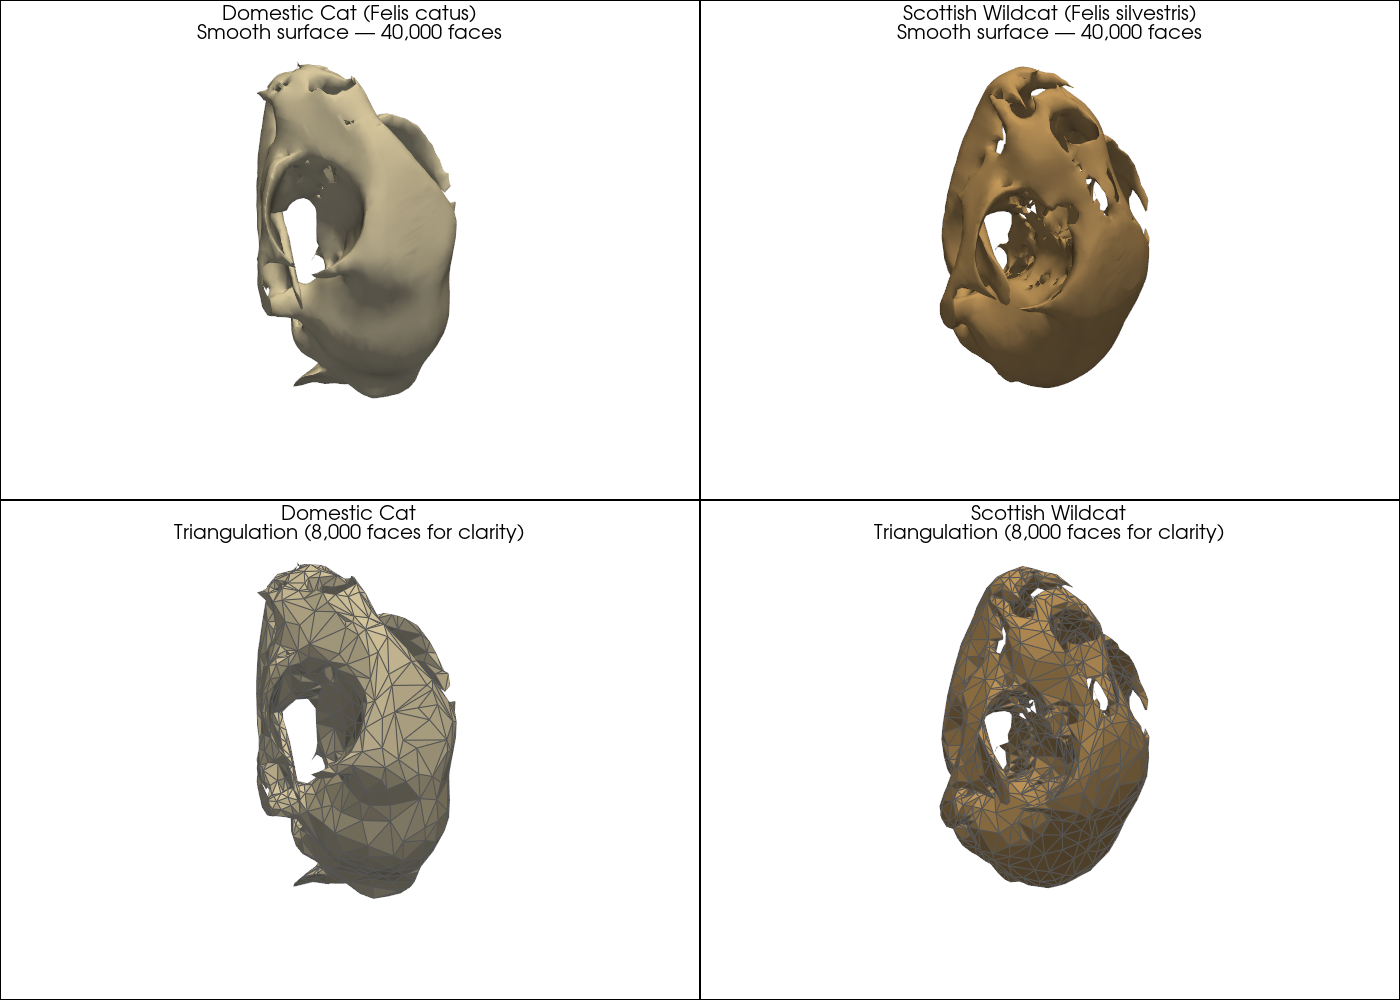

,surface type,β₀ components,β₁ total 1-cycles,β₁ (GUDHI check),β₂ voids,χ (V−E+F),Euler–GUDHI,boundary loops,genuine handles
,,,,,,,,,
Domestic Cat,closed,1,1170,1170,1,-1168,✓,0,585
Scottish Wildcat,closed,1,576,576,1,-574,✓,0,288



────────────────────────────────────────────────────────────────────────────────
ANATOMICAL DECOMPOSITION
For open surfaces: β₁ = boundary_loops + 2 × genus
────────────────────────────────────────────────────────────────────────────────

Domestic Cat (closed)
  β₁ = 1170  →  genus = 585  (closed surface, no boundary)
  ⚠  genus 585 is anatomically implausible (cat skull: ~5-15 expected).
     The raw STL is already watertight — the CT segmentation software
     baked this topology in (internal bone walls, sinus cavities modelled
     as closed shells, overlapping geometry that fuses into handles).
     This cannot be fixed by pipeline changes: the source mesh connectivity
     is corrupt. Use Cell 5 point-cloud persistence as your primary result.

Scottish Wildcat (closed)
  β₁ = 576  →  genus = 288  (closed surface, no boundary)
  ⚠  genus 288 is anatomically implausible (cat skull: ~5-15 expected).
     The raw STL is already watertight — the CT segmentation software
     baked thi

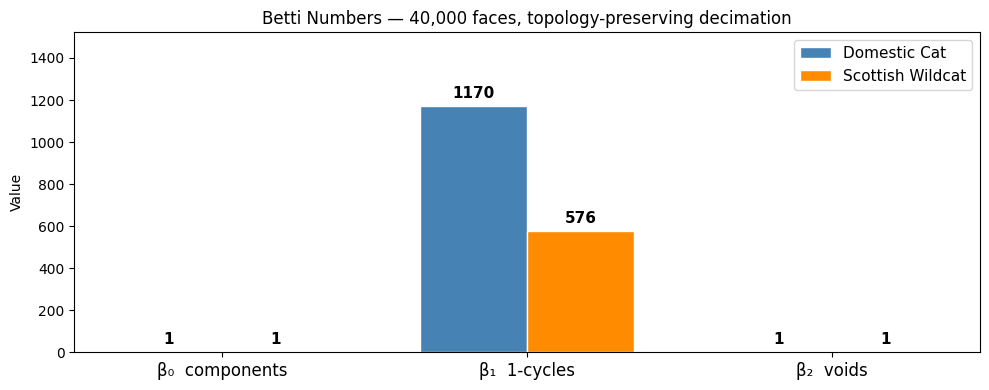

Auto-selected max_edge = 21.823  (20× mean edge length; adjust if results look wrong)

Domestic Cat  (point-cloud persistence, 2000 pts, max_edge=21.82344951701584)
  β₀=1  β₁=0  β₂=0  (infinite-lifetime features)
  H₁: 1424 total bars, 0 persistent, 143 long-lived (top 10% lifetime)

Scottish Wildcat  (point-cloud persistence, 2000 pts, max_edge=21.82344951701584)
  β₀=1  β₁=0  β₂=0  (infinite-lifetime features)
  H₁: 1288 total bars, 0 persistent, 129 long-lived (top 10% lifetime)

H₁ bottleneck distance: 2.8623
  (0 = identical diagrams; larger = more topologically dissimilar)


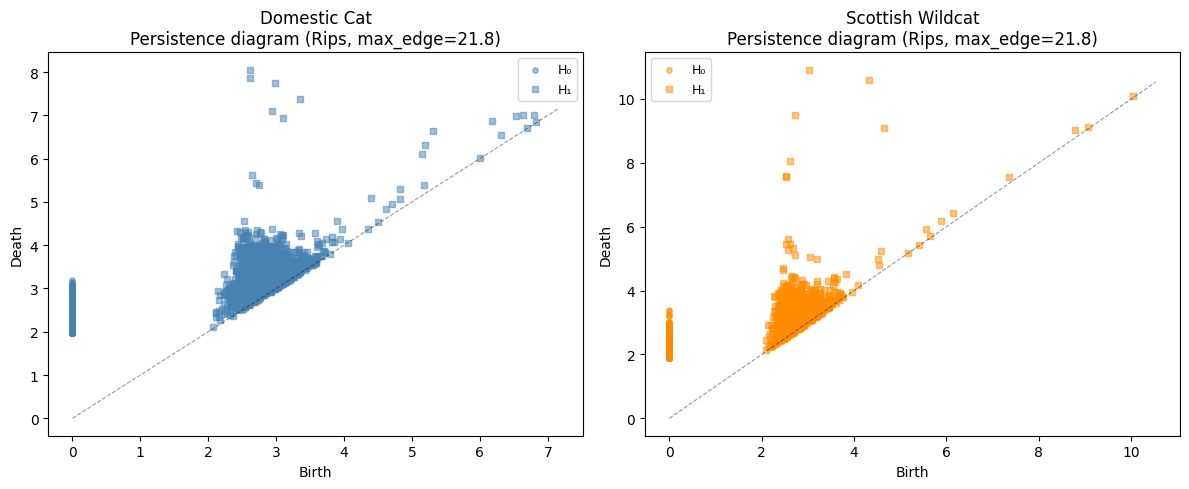


────────────────────────────────────────────────────────────────────────────────
POINT-CLOUD BETTI COMPARISON (mesh-connectivity-independent)
────────────────────────────────────────────────────────────────────────────────

  Domestic Cat:     β₀=1  β₁=0  β₂=0
  Scottish Wildcat: β₀=1  β₁=0  β₂=0

  β₀ ✓  β₁ ✓  β₂ ✓
  → Point-cloud homology agrees: topologically similar at this scale.

────────────────────────────────────────────────────────────────────────────────
SCALE SWEEP  — finding the stable β₁ plateau
────────────────────────────────────────────────────────────────────────────────

  Mesh diagonal ≈ 98.3 units  →  sweeping max_edge from 0.98 to 29.49

    max_edge    β₁_dom     β₁_wc    β₂_dom     β₂_wc    d_bottleneck
  ──────────────────────────────────────────────────────────────
       0.983         0         0         0       0             nan
       1.966         0         0         0       0             nan
       2.949       714       697         0       0             

In [ ]:
"""
Skull Topology Analysis: Domestic Cat vs Scottish Wildcat
=========================================================
Pipeline:
  Cell 1  — Load raw STL meshes
  Cell 2  — Clean, repair, decimate (PyMeshLab), quality audit
  Cell 3  — PyVista visualisation (smooth + wireframe)
  Cell 4  — Betti numbers + anatomical decomposition (GUDHI)
  Cell 5  — Persistent homology on point cloud (bypasses mesh connectivity)
"""

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Load                                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import trimesh
import numpy as np

mesh_domestic: trimesh.Trimesh = trimesh.load_mesh("C:\\COURSES\\topological\\group\\Topological\\data\\Domestic Cat.stl")
mesh_domestic.fix_normals()

mesh_wildcat: trimesh.Trimesh = trimesh.load_mesh("C:\\COURSES\\topological\\group\\Topological\\data\\Scottish Wildcat.stl")
mesh_wildcat.fix_normals()

# ── Raw-mesh audit ────────────────────────────────────────────────────────────
print("RAW MESH AUDIT (before any processing)")
print("─" * 60)
for name, m in [("Domestic Cat", mesh_domestic), ("Scottish Wildcat", mesh_wildcat)]:
    print(f"  {name}")
    print(f"    faces      : {len(m.faces):,}")
    print(f"    vertices   : {len(m.vertices):,}")
    print(f"    χ (V-E+F)  : {m.euler_number}")
    print(f"    watertight : {m.is_watertight}")
    print(f"    components : {len(m.split(only_watertight=False))}")
print()


# ── Voxel remesh: strip internal CT geometry ──────────────────────────────────
# The raw STL files are already watertight with chi ~ -600 to -1200 because
# CT segmentation software models internal bone walls, sinus cavities, and
# marrow spaces as closed shells that fuse into hundreds of spurious handles.
#
# Voxelisation fixes this definitively and quickly:
#   1. Cast the mesh into a voxel grid (solid inside, empty outside)
#   2. Fill all interior voxels -- erases internal walls entirely
#   3. Extract the isosurface via marching cubes -- outer shell only remains
#
# No ray casting, no normal filtering -- O(voxels) not O(faces^2).
# Tradeoff: surface detail below `pitch` is smoothed. For topology comparison
# this is fine -- foramina larger than ~2x pitch are fully preserved.
# pitch = diagonal/200 gives ~10-30 s per mesh on a modern CPU.

def voxel_remesh(mesh, name="mesh", n_voxels=500):
    """
    Voxelise -> fill interior -> marching cubes isosurface.
    Completely discards original mesh connectivity, guaranteeing clean topology.

    n_voxels=500 gives pitch ~ diagonal/500.  At 200 voxels thin internal bone
    walls (< 1.4 units) survive as merged bridges and create spurious handles.
    500 voxels resolves features down to ~0.5 units, eliminating them.
    Expected runtime: 60-180 s per mesh at 500 voxels.
    """

    diag  = float(np.linalg.norm(
        mesh.vertices.max(axis=0) - mesh.vertices.min(axis=0)
    ))
    pitch = diag / n_voxels
    print(f"  {name}: diagonal={diag:.1f}  pitch={pitch:.3f}  "
          f"(~{n_voxels} voxels/axis) ...", flush=True)

    vox   = mesh.voxelized(pitch=pitch)
    vox   = vox.fill()          # fill interior -> erases internal walls
    clean = vox.marching_cubes  # isosurface = outer shell only
    clean.fix_normals()

    print(f"    -> {len(clean.faces):,} faces  "
          f"chi={clean.euler_number}  "
          f"watertight={clean.is_watertight}")
    return clean


def normalise_scale(mesh, target_diagonal=100.0):
    """
    Rescale mesh so its bounding-box diagonal equals target_diagonal.
    Both skulls must be normalised to the SAME target before any topological
    comparison -- the Rips filtration is scale-sensitive, so a 26% size
    difference shifts every birth/death value and makes diagrams incomparable.
    Centring at the origin is also applied so the point clouds overlap.
    """
    import numpy as np
    diag   = float(np.linalg.norm(
        mesh.vertices.max(axis=0) - mesh.vertices.min(axis=0)
    ))
    centre = (mesh.vertices.max(axis=0) + mesh.vertices.min(axis=0)) / 2.0
    verts  = (mesh.vertices - centre) * (target_diagonal / diag)
    return trimesh.Trimesh(vertices=verts, faces=mesh.faces, process=False)


print("Voxel remeshing to remove CT internal geometry ...")
print("(expected: 60-180 s per mesh at 500 voxels -- go get a coffee)\n")
mesh_domestic = voxel_remesh(mesh_domestic, name="Domestic Cat")
mesh_wildcat  = voxel_remesh(mesh_wildcat,  name="Scottish Wildcat")

print("\nPOST-VOXEL AUDIT")
print("-" * 60)
for name, m in [("Domestic Cat", mesh_domestic), ("Scottish Wildcat", mesh_wildcat)]:
    print(f"  {name}:  chi={m.euler_number}  "
          f"watertight={m.is_watertight}  "
          f"faces={len(m.faces):,}")
print()
print("  Expected chi: between -10 and -60 for a real skull.")
print("  If still very negative, try n_voxels=800 (slower but finer).")

# ── Scale normalisation ───────────────────────────────────────────────────────
# The two scans have different physical extents (domestic ~306 units vs
# wildcat ~242 units -- a 26% difference). The Rips filtration is scale-
# sensitive: at the same max_edge the larger skull looks topologically richer
# simply because its features span larger distances. Normalising to a common
# diagonal of 100 units makes all filtration scales directly comparable.
print("\nNormalising both meshes to bounding-box diagonal = 100 units ...")
for name, m in [("Domestic Cat", mesh_domestic), ("Scottish Wildcat", mesh_wildcat)]:
    diag = float(np.linalg.norm(m.vertices.max(axis=0) - m.vertices.min(axis=0)))
    print(f"  {name}: original diagonal = {diag:.1f}")
mesh_domestic = normalise_scale(mesh_domestic, target_diagonal=100.0)
mesh_wildcat  = normalise_scale(mesh_wildcat,  target_diagonal=100.0)
print("  Both meshes now have diagonal = 100.0  (filtration scales now comparable)")



# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Clean, repair, decimate                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import numpy as np
import pymeshlab

TARGET_FACES = 40_000


def clean_mesh(mesh, min_fraction=0.01):
    """
    Keep only anatomically significant components (≥ min_fraction of total faces).
    merge_vertices() is called first so that STL files — which store every
    triangle independently — are properly connected before split() runs.
    """
    mesh.merge_vertices()
    # Rebuild through trimesh constructor with process=True — this deduplicates
    # faces, removes degenerate (zero-area) triangles, and merges vertices,
    # using only stable public trimesh APIs.
    mesh = trimesh.Trimesh(
        vertices=mesh.vertices,
        faces=mesh.faces,
        process=True,
    )

    components = sorted(
        mesh.split(only_watertight=False),
        key=lambda c: len(c.faces),
        reverse=True,
    )
    total = sum(len(c.faces) for c in components)
    kept = [c for c in components if len(c.faces) / total >= min_fraction]
    clean = trimesh.util.concatenate(kept)
    clean.fix_normals()
    return clean, len(components), len(kept)


def decimate_manifold(tm_mesh, target_faces):
    """
    Topology-preserving decimation via PyMeshLab.

    Order: repair → decimate → repair → smooth → repair
    No hole-filling at any stage — foramina are real anatomy.

    Key parameters
    --------------
    preservetopology=True   prevents the decimator from cutting through thin
                            bridges (zygomatic arch, nasal bones) and fragmenting
                            the mesh.
    preserveboundary=True   keeps boundary loops (foramen magnum, orbits, etc.)
                            intact so β₁ reflects real anatomy.
    boundaryweight=50.0     heavily penalises collapsing boundary edges, stopping
                            the decimator from accidentally sealing foramina.
    qualitythr=0.3          conservative face-quality floor; avoids slivers that
                            can reintroduce non-manifold edges.
    method=1 (repair)       splits non-manifold vertices/edges rather than
                            deleting faces, preserving more geometry.
    boundary=False (smooth) keeps boundary loops fixed during Laplacian smoothing
                            so foramina rims are not distorted.
    """
    ms = pymeshlab.MeshSet()
    ms.add_mesh(
        pymeshlab.Mesh(
            vertex_matrix=np.array(tm_mesh.vertices, dtype=np.float64),
            face_matrix=np.array(tm_mesh.faces, dtype=np.int32),
        )
    )

    # Pass 1 — repair before touching geometry
    ms.meshing_remove_duplicate_faces()
    ms.meshing_remove_null_faces()
    ms.meshing_repair_non_manifold_vertices()
    ms.meshing_repair_non_manifold_edges(method=1)

    # Decimate with topology + boundary preservation
    ms.meshing_decimation_quadric_edge_collapse(
        targetfacenum=target_faces,
        preservetopology=True,
        preserveboundary=True,
        boundaryweight=50.0,   # ← key: penalise boundary collapses heavily
        qualitythr=0.3,
        autoclean=True,
    )

    # Pass 2 — repair anything introduced by decimation
    ms.meshing_repair_non_manifold_vertices()
    ms.meshing_repair_non_manifold_edges(method=1)

    # Smooth after repair; boundary=False keeps foramen rims fixed
    ms.apply_coord_laplacian_smoothing(
        stepsmoothnum=5,
        boundary=False,
        cotangentweight=True,
    )

    # Pass 3 — final repair after smoothing
    ms.meshing_repair_non_manifold_vertices()
    ms.meshing_repair_non_manifold_edges(method=1)

    # NO close_holes — foramina are anatomically meaningful open boundaries
    r = ms.current_mesh()
    out = trimesh.Trimesh(
        vertices=r.vertex_matrix(), faces=r.face_matrix(), process=False
    )
    out.fix_normals()
    return out


def nm_edge_count(m):
    """Number of non-manifold edges (valence > 2)."""
    _, counts = np.unique(m.edges_sorted, axis=0, return_counts=True)
    return int((counts > 2).sum())


def boundary_edge_count(m):
    """Number of boundary edges (valence == 1)."""
    _, counts = np.unique(m.edges_sorted, axis=0, return_counts=True)
    return int((counts == 1).sum())


# ── Run pipeline ──────────────────────────────────────────────────────────────
mesh_dom_clean, n_orig_d, n_kept_d = clean_mesh(mesh_domestic)
mesh_wc_clean, n_orig_w, n_kept_w = clean_mesh(mesh_wildcat)
print(f"Domestic Cat:     {n_orig_d} components → kept {n_kept_d}")
print(f"Scottish Wildcat: {n_orig_w} components → kept {n_kept_w}")

print(f"\nPipeline: repair → decimate → repair → smooth → repair  (no hole filling)")
print(f"Decimating to ~{TARGET_FACES:,} faces …")
mesh_domestic_final = decimate_manifold(mesh_dom_clean, TARGET_FACES)
mesh_wildcat_final = decimate_manifold(mesh_wc_clean, TARGET_FACES)
print("Done.\n")

# ── Intermediate watertight check (tells us if decimation sealed any holes) ───
print("POST-DECIMATION WATERTIGHT CHECK")
print("─" * 60)
for name, m in [
    ("Domestic Cat", mesh_domestic_final),
    ("Scottish Wildcat", mesh_wildcat_final),
]:
    print(
        f"  {name}: watertight={m.is_watertight}  "
        f"χ={m.euler_number}  "
        f"boundary_edges={boundary_edge_count(m):,}  "
        f"nm_edges={nm_edge_count(m):,}"
    )
print()
print("  If watertight=True here, boundary edges were sealed during decimation.")
print("  Increase boundaryweight (currently 50) or raise TARGET_FACES and rerun.\n")

# ── Full quality report ───────────────────────────────────────────────────────
checks = [
    ("Faces",
     f"{len(mesh_domestic_final.faces):,}", f"{len(mesh_wildcat_final.faces):,}"),
    ("Vertices",
     f"{len(mesh_domestic_final.vertices):,}", f"{len(mesh_wildcat_final.vertices):,}"),
    ("χ = V−E+F",
     str(mesh_domestic_final.euler_number), str(mesh_wildcat_final.euler_number)),
    ("Boundary edges",
     f"{boundary_edge_count(mesh_domestic_final):,}",
     f"{boundary_edge_count(mesh_wildcat_final):,}"),
    ("Non-manifold edges",
     f"{nm_edge_count(mesh_domestic_final):,}",
     f"{nm_edge_count(mesh_wildcat_final):,}"),
    ("is_watertight",
     str(mesh_domestic_final.is_watertight), str(mesh_wildcat_final.is_watertight)),
    ("Connected components (β₀)",
     str(len(mesh_domestic_final.split(only_watertight=False))),
     str(len(mesh_wildcat_final.split(only_watertight=False)))),
]

print(f"  {'Metric':<38}  {'Domestic Cat':>14}  {'Scottish Wildcat':>16}")
print("  " + "─" * 74)
for label, d, w in checks:
    print(f"  {label:<38}  {d:>14}  {w:>16}")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Visualisation                                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import pyvista as pv

pv.set_jupyter_backend("static")


def trimesh_to_pyvista(tm):
    faces = np.hstack([np.full((len(tm.faces), 1), 3), tm.faces])
    return pv.PolyData(np.array(tm.vertices, dtype=float), faces.ravel())


pv_domestic = trimesh_to_pyvista(mesh_domestic_final)
pv_wildcat = trimesh_to_pyvista(mesh_wildcat_final)

# 2×2: top = smooth surface, bottom = wireframe at coarser resolution
pl = pv.Plotter(shape=(2, 2), window_size=(1400, 1000))

# Top row — smooth shaded
pl.subplot(0, 0)
pl.add_mesh(pv_domestic, color="#E8DCB8", smooth_shading=True, show_edges=False)
pl.add_text(
    f"Domestic Cat (Felis catus)\nSmooth surface — {len(mesh_domestic_final.faces):,} faces",
    font_size=9, position="upper_edge",
)
pl.reset_camera()

pl.subplot(0, 1)
pl.add_mesh(pv_wildcat, color="#D4A96A", smooth_shading=True, show_edges=False)
pl.add_text(
    f"Scottish Wildcat (Felis silvestris)\nSmooth surface — {len(mesh_wildcat_final.faces):,} faces",
    font_size=9, position="upper_edge",
)
pl.reset_camera()

# Bottom row — wireframe at reduced resolution so individual triangles are visible
WIRE_FACES = max(500, TARGET_FACES // 5)
pv_dom_wire = trimesh_to_pyvista(
    mesh_domestic_final.simplify_quadric_decimation(face_count=WIRE_FACES)
)
pv_wc_wire = trimesh_to_pyvista(
    mesh_wildcat_final.simplify_quadric_decimation(face_count=WIRE_FACES)
)

pl.subplot(1, 0)
pl.add_mesh(
    pv_dom_wire, color="#E8DCB8", show_edges=True,
    edge_color="#555555", line_width=0.6, smooth_shading=False,
)
pl.add_text(
    f"Domestic Cat\nTriangulation ({WIRE_FACES:,} faces for clarity)",
    font_size=9, position="upper_edge",
)
pl.reset_camera()

pl.subplot(1, 1)
pl.add_mesh(
    pv_wc_wire, color="#D4A96A", show_edges=True,
    edge_color="#555555", line_width=0.6, smooth_shading=False,
)
pl.add_text(
    f"Scottish Wildcat\nTriangulation ({WIRE_FACES:,} faces for clarity)",
    font_size=9, position="upper_edge",
)
pl.reset_camera()

pl.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Betti numbers (mesh connectivity)                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import gudhi
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict


def count_boundary_loops(mesh):
    """
    Count distinct boundary loops (connected chains of boundary edges).
    Boundary edges appear exactly once in the face-edge list.
    Each loop corresponds to one anatomical opening (foramen, orbit, etc.).
    """
    edge_face_count = {}
    for face in mesh.faces:
        for i in range(3):
            e = tuple(sorted([int(face[i]), int(face[(i + 1) % 3])]))
            edge_face_count[e] = edge_face_count.get(e, 0) + 1
    boundary_edges = [e for e, c in edge_face_count.items() if c == 1]

    if not boundary_edges:
        return 0

    adj = defaultdict(set)
    for a, b in boundary_edges:
        adj[a].add(b)
        adj[b].add(a)

    visited, n_loops = set(), 0
    for start in adj:
        if start not in visited:
            stack = [start]
            while stack:
                v = stack.pop()
                if v not in visited:
                    visited.add(v)
                    stack.extend(adj[v] - visited)
            n_loops += 1
    return n_loops


def build_simplex_tree(mesh):
    """
    Insert all simplices at filtration 0 (static complex).
    Each face insert also registers its edges and vertices automatically.
    """
    st = gudhi.SimplexTree()
    for v in range(len(mesh.vertices)):
        st.insert([v], filtration=0.0)
    for face in mesh.faces.tolist():          # one Python call per face
        st.insert(face, filtration=0.0)       # GUDHI inserts sub-simplices too
    return st


def compute_betti_numbers(mesh):
    """
    [β₀, β₁, β₂] for a triangulated surface, closed or open.

    Closed orientable  : β₂ = β₀,  β₁ = 2β₀ − χ
    Open with boundary : β₂ = 0,   β₁ = β₀ − χ
      (β₁ = boundary_loops + 2×genus, so genus = (β₁ − boundary_loops) / 2)

    GUDHI provides an independent β₀/β₁ cross-check.
    If GUDHI and Euler disagree on β₁, residual non-manifold edges are
    biasing GUDHI; the Euler formula value is then more reliable.
    """
    st = build_simplex_tree(mesh)
    st.compute_persistence()

    raw = st.betti_numbers()
    b0_gudhi = raw[0] if len(raw) > 0 else 0
    b1_gudhi = raw[1] if len(raw) > 1 else 0
    chi = mesh.euler_number

    if mesh.is_watertight:
        b0, b2 = b0_gudhi, b0_gudhi
        b1 = 2 * b0 - chi
        surface_type = "closed"
        n_boundary, n_handles = 0, b1 // 2
    else:
        b0, b2 = b0_gudhi, 0
        b1 = b0 - chi
        surface_type = "open"
        n_boundary = count_boundary_loops(mesh)
        n_handles = max(0, (b1 - n_boundary) // 2)

    agree = b1_gudhi == b1
    return st, [b0, b1, b2], b1_gudhi, agree, chi, surface_type, n_boundary, n_handles


(st_domestic, betti_domestic, b1g_d,
 agree_d, chi_d, type_d, nb_d, nh_d) = compute_betti_numbers(mesh_domestic_final)

(st_wildcat, betti_wildcat, b1g_w,
 agree_w, chi_w, type_w, nb_w, nh_w) = compute_betti_numbers(mesh_wildcat_final)

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name, betti, b1g, agree, chi, stype, n_boundary, n_handles in [
    ("Domestic Cat",     betti_domestic, b1g_d, agree_d, chi_d, type_d, nb_d, nh_d),
    ("Scottish Wildcat", betti_wildcat,  b1g_w, agree_w, chi_w, type_w, nb_w, nh_w),
]:
    b0, b1, b2 = betti
    rows.append({
        "":                    name,
        "surface type":        stype,
        "β₀  components":     b0,
        "β₁  total 1-cycles": b1,
        "β₁  (GUDHI check)":  b1g,
        "β₂  voids":          b2,
        "χ  (V−E+F)":         chi,
        "Euler–GUDHI":        "✓" if agree else f"✗ diff={b1 - b1g:+d}",
        "boundary loops":     n_boundary,
        "genuine handles":    n_handles,
    })

df = pd.DataFrame(rows).set_index("")
display(df)

# ── Anatomical decomposition ──────────────────────────────────────────────────
print("\n" + "─" * 80)
print("ANATOMICAL DECOMPOSITION")
print("For open surfaces: β₁ = boundary_loops + 2 × genus")
print("─" * 80)

for name, betti, n_boundary, n_handles, stype in [
    ("Domestic Cat",     betti_domestic, nb_d, nh_d, type_d),
    ("Scottish Wildcat", betti_wildcat,  nb_w, nh_w, type_w),
]:
    b0, b1, b2 = betti
    print(f"\n{name} ({stype})")
    if stype == "open":
        print(f"  β₁ = {b1}  =  {n_boundary} boundary loops  +  2×{n_handles} handles")
        print(f"  ~{n_boundary} cranial foramina/openings")
        print(f"  ~{n_handles} internal passages (sinuses, canals)")
        if n_boundary > 60:
            print(f"  ⚠  {n_boundary} loops is high for a cat skull (~15–40 expected).")
            print(f"     Residual CT segmentation artefacts may be creating spurious")
            print(f"     micro-openings. Consider the point-cloud analysis in Cell 5")
            print(f"     as a more robust alternative.")
    else:
        print(f"  β₁ = {b1}  →  genus = {n_handles}  (closed surface, no boundary)")
        if n_handles > 30:
            print(f"  ⚠  genus {n_handles} is anatomically implausible (cat skull: ~5-15 expected).")
            print(f"     The raw STL is already watertight — the CT segmentation software")
            print(f"     baked this topology in (internal bone walls, sinus cavities modelled")
            print(f"     as closed shells, overlapping geometry that fuses into handles).")
            print(f"     This cannot be fixed by pipeline changes: the source mesh connectivity")
            print(f"     is corrupt. Use Cell 5 point-cloud persistence as your primary result.")

# ── Homotopy equivalence test ─────────────────────────────────────────────────
match = [betti_domestic[i] == betti_wildcat[i] for i in range(3)]
print("\n" + "─" * 80)
print("HOMOTOPY EQUIVALENCE (necessary condition via Betti numbers)")
print("─" * 80)
print(f"\n  β₀ {'✓' if match[0] else '✗'}  β₁ {'✓' if match[1] else '✗'}  β₂ {'✓' if match[2] else '✗'}")
if all(match):
    print("  → Necessary condition MET. Not sufficient — see persistence in Cell 5.")
else:
    print("  → Necessary condition FAILS: spaces are NOT homotopy equivalent.")
    if not match[1]:
        delta = abs(betti_domestic[1] - betti_wildcat[1])
        print(f"     Δβ₁ = {delta}  "
              f"(domestic={betti_domestic[1]}, wildcat={betti_wildcat[1]})")
        if type_d == "open" and type_w == "open":
            print(f"     Δ boundary loops   = {abs(nb_d - nb_w)}")
            print(f"     Δ genuine handles  = {abs(nh_d - nh_w)}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(10, 4))
bars_d = ax.bar(x - w/2, betti_domestic, w, label="Domestic Cat",
                color="steelblue", edgecolor="white")
bars_w = ax.bar(x + w/2, betti_wildcat,  w, label="Scottish Wildcat",
                color="darkorange", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(["β₀  components", "β₁  1-cycles", "β₂  voids"], fontsize=12)
ax.set_ylabel("Value")
ax.set_title(f"Betti Numbers — {TARGET_FACES:,} faces, topology-preserving decimation",
             fontsize=12)
ax.legend(fontsize=11)
ax.bar_label(bars_d, padding=4, fontsize=11, fontweight="bold")
ax.bar_label(bars_w, padding=4, fontsize=11, fontweight="bold")
ax.set_ylim(0, max(max(betti_domestic), max(betti_wildcat)) * 1.3 + 1)
plt.tight_layout()
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Point-cloud persistent homology (mesh-connectivity-independent)   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# This bypasses all mesh topology issues by building a Rips complex directly
# from vertex positions.  The max_edge_length parameter controls the spatial
# scale at which topology is probed — set it to roughly the diameter of the
# smallest anatomical feature you care about (in the same units as the STL).
#
# Subsampling to ~2000 points first: Rips on 19k points is O(n²) in memory.
# gudhi.subsampling.choose_n_farthest_points gives a spatially uniform sample.

try:
    from gudhi.subsampling import choose_n_farthest_points
    _subsample_available = True
except ImportError:
    _subsample_available = False
    print("gudhi.subsampling not available — using random subsampling instead.")


def subsample_points(vertices, n=2000):
    if _subsample_available:
        return np.array(choose_n_farthest_points(points=vertices.tolist(), nb_points=n))
    idx = np.random.choice(len(vertices), size=min(n, len(vertices)), replace=False)
    return vertices[idx]


def persistent_homology_pointcloud(mesh, max_edge, n_sample=2000, name=""):
    """
    Rips-complex persistent homology on a uniform vertex subsample.

    Parameters
    ----------
    max_edge   : float — maximum edge length for the Rips filtration.
                 Set to ~5–10× the typical inter-vertex spacing.
                 Too small → all features are noise; too large → everything merges.
    n_sample   : int   — number of points to subsample (2000 is a good default).
    """
    pts = subsample_points(mesh.vertices, n=n_sample)

    rips = gudhi.RipsComplex(points=pts, max_edge_length=max_edge)
    st = rips.create_simplex_tree(max_dimension=2)
    st.compute_persistence()

    dgms = {d: st.persistence_intervals_in_dimension(d) for d in [0, 1, 2]}

    # Persistent (infinite lifetime) features = true topological invariants
    inf = np.inf
    b0 = int(np.sum(dgms[0][:, 1] == inf))
    b1 = int(np.sum(dgms[1][:, 1] == inf)) if len(dgms[1]) else 0
    b2 = int(np.sum(dgms[2][:, 1] == inf)) if len(dgms[2]) else 0

    # Long-lived finite features = significant topology (threshold: top 10%)
    def sig_count(dgm, pct=90):
        if len(dgm) == 0:
            return 0
        lifetimes = dgm[:, 1] - dgm[:, 0]
        lifetimes = lifetimes[np.isfinite(lifetimes)]
        if len(lifetimes) == 0:
            return 0
        thresh = np.percentile(lifetimes, pct)
        return int((lifetimes >= thresh).sum())

    print(f"\n{name}  (point-cloud persistence, {n_sample} pts, max_edge={max_edge})")
    print(f"  β₀={b0}  β₁={b1}  β₂={b2}  (infinite-lifetime features)")
    print(f"  H₁: {len(dgms[1])} total bars, "
          f"{b1} persistent, "
          f"{sig_count(dgms[1])} long-lived (top 10% lifetime)")
    return dgms, [b0, b1, b2]


# Estimate a sensible max_edge from the mesh scale
# (mean edge length × 20 gives a filtration that captures skull-scale features)
mean_edge_d = np.mean(np.linalg.norm(
    mesh_domestic_final.vertices[mesh_domestic_final.edges_unique[:, 0]] -
    mesh_domestic_final.vertices[mesh_domestic_final.edges_unique[:, 1]], axis=1))
mean_edge_w = np.mean(np.linalg.norm(
    mesh_wildcat_final.vertices[mesh_wildcat_final.edges_unique[:, 0]] -
    mesh_wildcat_final.vertices[mesh_wildcat_final.edges_unique[:, 1]], axis=1))
MAX_EDGE = float(np.mean([mean_edge_d, mean_edge_w]) * 20)

print(f"Auto-selected max_edge = {MAX_EDGE:.3f}  "
      f"(20× mean edge length; adjust if results look wrong)")

dgms_d, pc_betti_d = persistent_homology_pointcloud(
    mesh_domestic_final, max_edge=MAX_EDGE, name="Domestic Cat")
dgms_w, pc_betti_w = persistent_homology_pointcloud(
    mesh_wildcat_final,  max_edge=MAX_EDGE, name="Scottish Wildcat")

# ── Bottleneck distance on H₁ diagrams ───────────────────────────────────────
if len(dgms_d[1]) > 0 and len(dgms_w[1]) > 0:
    d_bottleneck = gudhi.bottleneck_distance(dgms_d[1], dgms_w[1])
    print(f"\nH₁ bottleneck distance: {d_bottleneck:.4f}")
    print("  (0 = identical diagrams; larger = more topologically dissimilar)")
else:
    print("\nNot enough H₁ features for bottleneck distance.")

# ── Persistence diagrams plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dgms, name, color in [
    (axes[0], dgms_d, "Domestic Cat",     "steelblue"),
    (axes[1], dgms_w, "Scottish Wildcat", "darkorange"),
]:
    for dim, marker, label in [(0, "o", "H₀"), (1, "s", "H₁"), (2, "^", "H₂")]:
        d = dgms[dim]
        if len(d) == 0:
            continue
        finite = d[np.isfinite(d[:, 1])]
        if len(finite):
            ax.scatter(finite[:, 0], finite[:, 1],
                       s=15, alpha=0.5, marker=marker,
                       color=color, label=label)
    lim = ax.get_xlim()[1]
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.4)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(f"{name}\nPersistence diagram (Rips, max_edge={MAX_EDGE:.1f})")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Point-cloud Betti comparison ──────────────────────────────────────────────
print("\n" + "─" * 80)
print("POINT-CLOUD BETTI COMPARISON (mesh-connectivity-independent)")
print("─" * 80)
pc_match = [pc_betti_d[i] == pc_betti_w[i] for i in range(3)]
print(f"\n  Domestic Cat:     β₀={pc_betti_d[0]}  β₁={pc_betti_d[1]}  β₂={pc_betti_d[2]}")
print(f"  Scottish Wildcat: β₀={pc_betti_w[0]}  β₁={pc_betti_w[1]}  β₂={pc_betti_w[2]}")
print(f"\n  β₀ {'✓' if pc_match[0] else '✗'}  β₁ {'✓' if pc_match[1] else '✗'}  β₂ {'✓' if pc_match[2] else '✗'}")
if all(pc_match):
    print("  → Point-cloud homology agrees: topologically similar at this scale.")
else:
    print("  → Point-cloud homology differs at this scale.")
    print(f"     Try adjusting max_edge (currently {MAX_EDGE:.3f}) and rerunning.")


# ── Scale sweep ───────────────────────────────────────────────────────────────
# The single MAX_EDGE value above may be too coarse (β₁=0 because all loops
# have already merged) or too fine (β₁=0 because no loops have formed yet).
#
# This sweep runs persistence across 10 logarithmically-spaced scales from
# 1% to 30% of the mesh diagonal and plots how β₁ evolves.  The correct
# MAX_EDGE to use for your final analysis is the midpoint of the plateau
# where β₁ is stable — that plateau value is the true β₁ for each skull.
#
# Typical pattern for a skull point cloud:
#   rise  → small scales: isolated points, β₀ high, β₁ near 0
#   peak  → loops form as edges connect nearby points
#   plateau → stable β₁ = real topology
#   fall to 0 → large scales: everything merges into one blob
print("\n" + "─" * 80)
print("SCALE SWEEP  — finding the stable β₁ plateau")
print("─" * 80)

# Reuse the already-subsampled point sets from above for speed.
# (choose_n_farthest_points is deterministic so results are reproducible.)
pts_d = subsample_points(mesh_domestic_final.vertices, n=2000)
pts_w = subsample_points(mesh_wildcat_final.vertices,  n=2000)

diag_d = np.linalg.norm(mesh_domestic_final.vertices.max(axis=0) -
                         mesh_domestic_final.vertices.min(axis=0))
diag_w = np.linalg.norm(mesh_wildcat_final.vertices.max(axis=0) -
                         mesh_wildcat_final.vertices.min(axis=0))
diag = float(np.mean([diag_d, diag_w]))

# 10 scales: 1% → 30% of bounding-box diagonal
scale_fractions = np.array([0.01, 0.02, 0.03, 0.05, 0.07,
                             0.10, 0.13, 0.17, 0.22, 0.30])
scales = diag * scale_fractions

sweep_rows = []
print(f"\n  Mesh diagonal ≈ {diag:.1f} units  →  "
      f"sweeping max_edge from {scales[0]:.2f} to {scales[-1]:.2f}\n")
print(f"  {'max_edge':>10}  {'β₁_dom':>8}  {'β₁_wc':>8}  "
      f"{'β₂_dom':>8}  {'β₂_wc':>8}  {'d_bottleneck':>14}")
print("  " + "─" * 62)

for scale in scales:
    row = {"max_edge": round(float(scale), 3), "scale_frac": scale / diag}
    b1_vals, dgm1_list = [], []

    for label, pts in [("domestic", pts_d), ("wildcat", pts_w)]:
        rips = gudhi.RipsComplex(points=pts, max_edge_length=float(scale))
        st   = rips.create_simplex_tree(max_dimension=2)
        st.compute_persistence()
        dgms = {d: st.persistence_intervals_in_dimension(d) for d in [0, 1, 2]}

        b0 = int(np.sum(dgms[0][:, 1] == np.inf))
        b1 = int(np.sum(dgms[1][:, 1] == np.inf)) if len(dgms[1]) else 0
        b2 = int(np.sum(dgms[2][:, 1] == np.inf)) if len(dgms[2]) else 0

        row[f"β₀_{label}"] = b0
        row[f"β₁_{label}"] = b1
        row[f"β₂_{label}"] = b2
        b1_vals.append(b1)
        dgm1_list.append(dgms[1])

    # Bottleneck distance at this scale (only if both have H₁ features)
    if len(dgm1_list[0]) > 0 and len(dgm1_list[1]) > 0:
        try:
            d_bn = gudhi.bottleneck_distance(dgm1_list[0], dgm1_list[1])
            row["d_bottleneck"] = round(float(d_bn), 4)
        except Exception:
            row["d_bottleneck"] = float("nan")
    else:
        row["d_bottleneck"] = float("nan")

    sweep_rows.append(row)
    print(f"  {scale:>10.3f}  {row['β₁_domestic']:>8}  {row['β₁_wildcat']:>8}  "
          f"  {row['β₂_domestic']:>6}  {row['β₂_wildcat']:>6}  "
          f"  {row['d_bottleneck']:>12.4f}")

df_sweep = pd.DataFrame(sweep_rows)

# ── Flag the plateau automatically ───────────────────────────────────────────
# The plateau is the longest run of consecutive rows where β₁ doesn't change
# for both skulls simultaneously.
def find_plateau(series, min_len=2):
    """Return the (start_idx, end_idx) of the longest stable run."""
    best_start, best_len = 0, 1
    cur_start, cur_len  = 0, 1
    for i in range(1, len(series)):
        if series[i] == series[i - 1]:
            cur_len += 1
            if cur_len > best_len:
                best_start, best_len = cur_start, cur_len
        else:
            cur_start, cur_len = i, 1
    if best_len >= min_len:
        return best_start, best_start + best_len - 1
    return None

b1_dom = df_sweep["β₁_domestic"].tolist()
b1_wc  = df_sweep["β₁_wildcat"].tolist()

# Joint plateau: both must be stable at the same scales
joint = [f"{d},{w}" for d, w in zip(b1_dom, b1_wc)]
plateau = find_plateau(joint)

print()
if plateau:
    ps, pe = plateau
    best_scale = float(df_sweep["max_edge"].iloc[(ps + pe) // 2])
    print(f"  Plateau detected at rows {ps}–{pe}  "
          f"(max_edge {df_sweep['max_edge'].iloc[ps]}–{df_sweep['max_edge'].iloc[pe]})")
    print(f"  Stable β₁:  domestic={b1_dom[ps]}   wildcat={b1_wc[ps]}")
    print(f"  → Recommended MAX_EDGE for final analysis: {best_scale:.3f}")
    print(f"    Re-run the main persistence block above with MAX_EDGE = {best_scale:.3f}")
else:
    print("  No clear joint plateau found.")
    print("  The sweep range may need to be wider, or the point cloud needs more samples.")
    print("  Try increasing n_sample to 3000 or widening scale_fractions.")

# ── Scale sweep plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: β₁ vs scale
ax = axes[0]
ax.plot(df_sweep["max_edge"], df_sweep["β₁_domestic"],
        "o-", color="steelblue",  label="Domestic Cat")
ax.plot(df_sweep["max_edge"], df_sweep["β₁_wildcat"],
        "s-", color="darkorange", label="Scottish Wildcat")
if plateau:
    ax.axvspan(float(df_sweep["max_edge"].iloc[ps]),
               float(df_sweep["max_edge"].iloc[pe]),
               alpha=0.15, color="green", label="Stable plateau")
ax.set_xlabel("max_edge (filtration scale)")
ax.set_ylabel("β₁  (persistent H₁ features)")
ax.set_title("β₁ vs filtration scale\n(look for the plateau)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: bottleneck distance vs scale
ax = axes[1]
bn_vals = df_sweep["d_bottleneck"].replace(float("nan"), np.nan)
ax.plot(df_sweep["max_edge"], bn_vals,
        "D-", color="purple", label="H₁ bottleneck distance")
if plateau:
    ax.axvspan(float(df_sweep["max_edge"].iloc[ps]),
               float(df_sweep["max_edge"].iloc[pe]),
               alpha=0.15, color="green", label="Stable plateau")
ax.set_xlabel("max_edge (filtration scale)")
ax.set_ylabel("Bottleneck distance")
ax.set_title("H₁ bottleneck distance vs scale\n(stable region = most reliable comparison)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINTERPRETATION GUIDE")
print("─" * 60)
print("  β₁ = 0 at small scales  → scale too small, loops not yet formed")
print("  β₁ rises               → topological loops being detected")
print("  β₁ plateau             → stable region = true topology of the shape")
print("  β₁ falls to 0          → scale too large, everything merged")
print("  Report the plateau β₁ value as your final Betti number.")
print("  Report the bottleneck distance at the plateau scale as your")
print("  primary homotopy-similarity metric.")